In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import expon
from bayesian_dro.Bayesian_DRO_continuous import data_generation
from mis_dro.dataset import data_generation_outliers, data_generation_gamma
from bayesian_dro.Bayesian_DRO_continuous import EPSILON_SET

/tmp/dcs-tmp.u1604520/ipykernel_1131759/2478035765.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [25]:
experiment_dir = "/dcs/pg23/u1604520/misdro/results_kdro/n100/"
experiment_dir_bdro = "/dcs/pg23/u1604520/misdro/results_kdro/n100/"
# results_df = pd.read_csv(experiment_dir / "results.csv", index_col="uuid")
#results_other_dgps_df = pd.read_csv(experiment_dir / "results_patrick.csv", index_col="uuid")
#results_df = pd.concat([results_other_dgps_df, results_gamma_df])
dfs = []
# for dir in [experiment_dir, experiment_dir_bdro]:
for alg in ['kdro', 'bdro']:
    for epsilon in EPSILON_SET:
        # if dir == experiment_dir:
        if alg == 'kdro':
            file_path = experiment_dir + f"{alg}_exp_N100_ncert_100_{epsilon}.csv" #f"kdro_cont_normal_N400_{epsilon}.csv"   #test_results_eps_{epsilon}.csv
        else:
        # file_path = dir + f"bdro_exp_N100_ncert_20_{epsilon}.csv"
            file_path = experiment_dir_bdro + f"{alg}_exp_N100_ncert_100_{epsilon}.csv"
        
        df = pd.read_csv(file_path)
        df['epsilon'] = epsilon
        # if dir == experiment_dir:
        if alg == 'kdro':
            df['algorithm'] = 'mmd-dro'
        else:
            df['algorithm'] = 'bdro'
        dfs.append(df)
results_df = pd.concat(dfs, ignore_index=True)
# check the number of train/test observations is the same:
# assert len(results_df["num_observations"].unique()) == 1
# assert len(results_df["num_test_observations"].unique()) == 1
# num_observations = results_df["num_observations"]
# num_test_observations = results_df["num_test_observations"]
results_df

,replication,mean_cost,var_cost,solution,dgp_time,likelihood_time,posterior_time,solve_time,epsilon,algorithm
0,0,37.973527,1813.705591,14.692639,0.000550,0.004923,121.966830,26.129209,0.001,mmd-dro
1,1,30.962813,481.662388,12.545785,0.000885,0.003554,108.950599,24.438856,0.001,mmd-dro
2,2,39.877380,1782.280530,14.311508,0.000881,0.001795,85.853045,24.252739,0.001,mmd-dro
3,3,38.435708,786.463015,20.812534,0.000801,0.001839,85.333729,24.636805,0.001,mmd-dro
4,4,42.725730,1108.483017,14.291473,0.000794,0.001872,83.911956,24.627383,0.001,mmd-dro
...,...,...,...,...,...,...,...,...,...,...
3595,95,99.016280,508.783137,41.810000,0.000518,0.000647,0.000122,227.319679,3.000,bdro
3596,96,109.789898,5343.282248,38.530000,0.000500,0.000644,0.000118,225.225447,3.000,bdro
3597,97,85.966793,615.652803,36.410000,0.000525,0.000641,0.000119,238.774098,3.000,bdro
3598,98,90.833595,890.329615,39.750000,0.000492,0.000663,0.000115,226.769765,3.000,bdro


In [21]:
results_df = results_df[results_df['epsilon'] < 0.4]

In [27]:
gb = results_df.groupby(by=["algorithm", "epsilon"])
df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    "posterior_time": ["mean"],
    "solve_time": ["mean"],
    "solution": ["mean", "var"]
})
df

mean_cost                  var_cost posterior_time  \
                         mean          var         mean           mean   
algorithm epsilon                                                        
bdro      0.001     47.373969   123.863722  1262.192511       0.000119   
          0.002     47.675388   115.093449  1222.095958       0.000119   
          0.005     48.508932   126.487414  1186.798626       0.000119   
          0.010     49.354512   126.845383  1147.040001       0.000119   
          0.020     50.658800   132.231987  1097.234602       0.000119   
          0.050     53.456079   141.949885  1007.356905       0.000119   
          0.100     56.518490   164.450172   931.964266       0.000119   
          0.150     58.899013   179.881480   887.096125       0.000119   
          0.200     60.988913   196.844224   854.517282       0.000119   
          0.250     62.768908   210.050842   831.077163       0.000119   
          0.300     64.409121   224.803296   816.090124       0.000119   
          0.400     67.333229   253.836756   792.848391       0.000119   
          0.500     69.750572   276.439262   782.262700       0.000119   
          1.000     78.642200   409.529990   765.021064       0.000119   
          1.500     82.718838   506.370622   746.407577       0.000119   
          2.000     94.676870   805.516763   727.417931       0.000119   
          2.500     94.680605   805.616514   727.412515       0.000119   
          3.000     94.680605   805.616514   727.412515       0.000119   
mmd-dro   0.001     39.676304   102.535239  1964.141122      84.569881   
          0.002     39.692778   101.886411  1955.543512      84.569881   
          0.005     39.752562   100.894425  1932.381858      84.569881   
          0.010     39.892630    99.969380  1901.025562      84.569881   
          0.020     40.137059    97.937007  1845.654871      84.569881   
          0.050     40.940046    94.964651  1717.359303      84.569881   
          0.100     42.358997    93.112781  1521.842906      84.569881   
          0.150     44.496300    98.402046  1330.036709      84.569881   
          0.200     47.449754   110.028648  1147.816442      84.569881   
          0.250     51.542021   140.939202   986.431803      84.569881   
          0.300     57.688553   201.969394   840.917051      84.569881   
          0.400     94.752493  1137.538313   676.226497      84.569881   
          0.500    100.505532  1412.916677   680.554081      84.569881   
          1.000    103.877532  1506.873941   681.188730      84.569881   
          1.500    103.877532  1506.873917   681.188728      84.569881   
          2.000    103.877532  1506.873934   681.188725      84.569881   
          2.500    103.877532  1506.873944   681.188729      84.569881   
          3.000    103.877532  1506.873948   681.188732      84.569881   

                   solve_time   solution              
                         mean       mean         var  
algorithm epsilon                                     
bdro      0.001    232.351269  21.003900   19.281165  
          0.002    232.351269  21.257600   17.364178  
          0.005    232.351269  21.724900   18.914122  
          0.010    232.351269  22.236100   18.784367  
          0.020    232.351269  22.960300   19.413785  
          0.050    232.351269  24.421500   20.681029  
          0.100    232.351269  25.906100   23.381289  
          0.150    232.351269  26.996700   24.829483  
          0.200    232.351269  27.895500   26.516271  
          0.250    232.351269  28.645500   27.689116  
          0.300    232.351269  29.319900   29.126654  
          0.400    232.351269  30.515900   31.910835  
          0.500    232.351269  31.476900   34.404731  
          1.000    232.351269  34.822500   49.356366  
          1.500    232.351269  36.294800   60.632328  
          2.000    232.351269  40.619800   92.524521  
          2.500    232.351269  40.621100   92.534481  
          3.000    232.351269  40

In [2]:
def plot_dgp(df, dgp: str, axis, Nsamples):
    # get a dataframe for each posterior
    bayes_df = df.loc["bdro", :]
    kdro_df = df.loc['kdro', :]
    mmd_df = df.loc["mmd-dro", :]

    # # mean of variances + variance of means
    bayes_bootstrap_var = bayes_df["var_cost"]["mean"] + bayes_df["mean_cost"]["var"]
    kdro_bootstrap_var = kdro_df["var_cost"]["mean"] + kdro_df["mean_cost"]["var"]
    mmd_bootstrap_var = mmd_df["var_cost"]["mean"] + mmd_df["mean_cost"]["var"]

    # plot mean-variance trade-off
    axis.plot(bayes_bootstrap_var, bayes_df["mean_cost"]["mean"], marker='o', linestyle="solid", label="BDRO")
    axis.plot(kdro_bootstrap_var, kdro_df["mean_cost"]["mean"], marker="x", linestyle="dashed", label="BAS-DRO (MMD-NPL)")
    axis.plot(mmd_bootstrap_var, mmd_df["mean_cost"]["mean"], marker="v", linestyle="dotted", label="MMD-DRO")

    # set title and label epsilon
    axis.set_title(f"DGP is {dgp}, {Nsamples} samples")
    axis.legend()
    axis.set_xlabel("out-of-sample variance")
    axis.set_ylabel("out-of-sample mean")
    for i, epsilon in enumerate(mmd_df.index.get_level_values("epsilon")):
        if i % 4 == 0:
            axis.text(bayes_bootstrap_var[epsilon], bayes_df["mean_cost"]["mean"][epsilon], epsilon, ha='left', va='bottom')
        if (i+2) % 4 == 0:
            axis.text(mmd_bootstrap_var[epsilon], mmd_df["mean_cost"]["mean"][epsilon], epsilon, ha='right', va='bottom')

# plot mean-variance trade-off for each DGP
# dgp_list = list(df.index.get_level_values("dgp").unique())
# nrows = int(np.ceil(len(dgp_list)/2.0))
# fig, axes = plt.subplots(nrows=nrows, ncols=2, sharex=False, sharey=False, figsize=(10,10))
# for i, dgp in enumerate(dgp_list):
#     row = int(np.floor(i / 2.0))
#     col = i % 2
#     plot_dgp(dgp, axes[row][col])

NameError: name 'df' is not defined

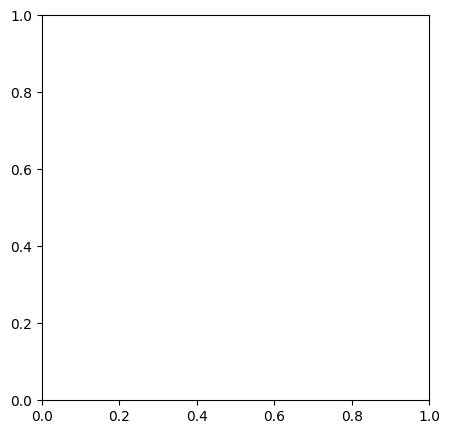

In [3]:
fig, axis = plt.subplots(nrows=1, ncols=1, sharex=False, sharey=False, figsize=(5,5))
plot_dgp(df, 'wellsp_exp', axis, 100)

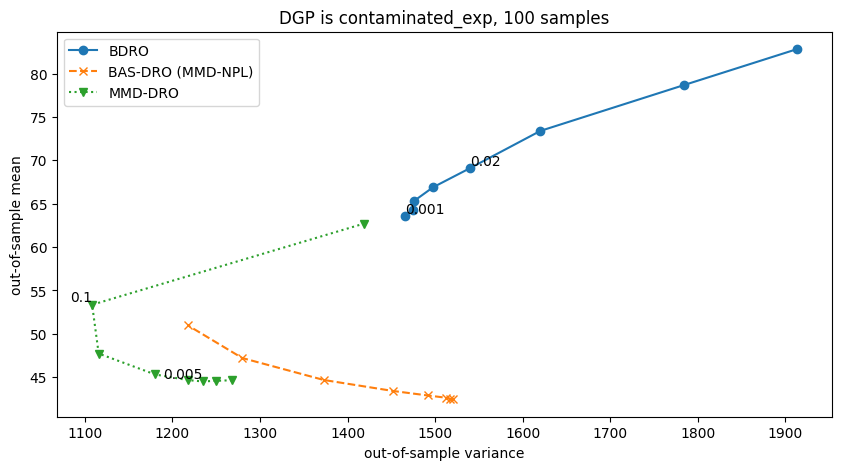

In [5]:
experiment_dir = "/dcs/pg23/u1604520/misdro/results_kdro/n100/"
experiment_dir_bdro = "/dcs/pg23/u1604520/misdro/results_kdro/n100/"
fig, axes = plt.subplots(nrows=1, ncols=1, sharex=False, sharey=False, figsize=(10,5))
N_values = [100] #, 400]
for i, N in enumerate(N_values):
    dfs = []
    for alg in ['bdro', 'kdro', 'mmd-dro']: #, 
        for epsilon in EPSILON_SET:
            if alg == 'bdro':
                file_path = experiment_dir_bdro + f"bdro_cont_exp_N100_ncert_200_cont_0.2_{epsilon}.csv" #f"kdro_cont_normal_N400_{epsilon}.csv"   #test_results_eps_{epsilon}.csv
            elif alg == 'kdro':
                file_path = experiment_dir + f"kdro_cont_exp_N100_ncert_200_cont_0.2_{epsilon}.csv"   # same exp just wrong file name
            else:
                file_path = experiment_dir + f"mmd_cont_exp_N{N}_ncert_200_cont_0.2_{epsilon}.csv" 
        
            df = pd.read_csv(file_path)
            df['epsilon'] = epsilon
            
            df['algorithm'] = alg
    
            dfs.append(df)
            
    results_df = pd.concat(dfs, ignore_index=True)
    results_df = results_df[results_df['epsilon'] < 0.2]
    gb = results_df.groupby(by=["algorithm", "epsilon"])
    df = gb.agg({
        "mean_cost": ["mean", "var"],
        "var_cost": ["mean"],
        "posterior_time": ["mean"],
        "solve_time": ["mean"],
        "solution": ["mean", "var"]
    })
    plot_dgp(df, 'contaminated_exp', axes, N)
plt.show()

In [7]:
from scipy.stats import truncnorm
b = 8
h = 3
L = 100

DGP_MEAN_TRUNCATED_NORMAL = 10
DGP_STD_TRUNCATED_NORMAL = 10

NUM_OBSERVATIONS = 20
sol_true = truncnorm.ppf(
        (b - 0) / (h + b), a=-DGP_MEAN_TRUNCATED_NORMAL / DGP_STD_TRUNCATED_NORMAL, b=np.inf, loc=DGP_MEAN_TRUNCATED_NORMAL, scale=DGP_STD_TRUNCATED_NORMAL
    )

In [8]:
sol_true

17.406341169581744

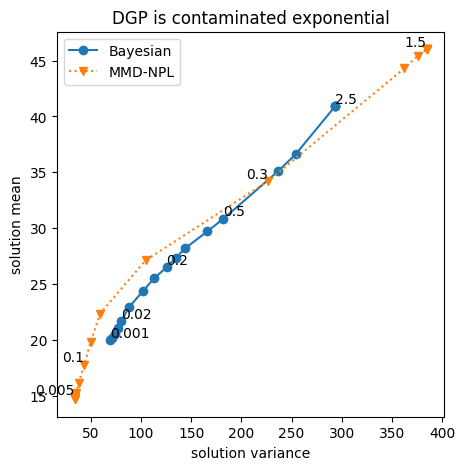

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=1, sharex=False, sharey=False, figsize=(5,5))
bayes_df = df.loc["bdro", :]
mmd_df = df.loc["mmd-dro", :]

bayes_bootstrap_var = bayes_df["solution"]["mean"] + bayes_df["solution"]["var"]
mmd_bootstrap_var = mmd_df["solution"]["mean"] + mmd_df["solution"]["var"]

# plot mean-variance trade-off
ax.plot(bayes_bootstrap_var, bayes_df["solution"]["mean"], marker='o', linestyle="solid", label="Bayesian")
    # axis.plot(wll_bootstrap_var, wll_df["mean_cost"]["mean"], marker="x", linestyle="dashed", label="WLL-NPL")
ax.plot(mmd_bootstrap_var, mmd_df["solution"]["mean"], marker="v", linestyle="dotted", label="MMD-NPL")

# set title and label epsilon
ax.set_title("DGP is contaminated exponential")
ax.legend()
ax.set_xlabel("solution variance")
ax.set_ylabel("solution mean")
for i, epsilon in enumerate(mmd_df.index.get_level_values("epsilon")):
    if i % 4 == 0:
        ax.text(bayes_bootstrap_var[epsilon], bayes_df["solution"]["mean"][epsilon], epsilon, ha='left', va='bottom')
    if (i+2) % 4 == 0:
        ax.text(mmd_bootstrap_var[epsilon], mmd_df["solution"]["mean"][epsilon], epsilon, ha='right', va='bottom')

Number of certifying points 

In [21]:
n_cert_values = [5, 20, 100]
experiment_dir = "/dcs/pg23/u1604520/misdro/results_kdro/ncert/"
dfs = []
for ncert in n_cert_values:
    for epsilon in EPSILON_SET:
        file_path = experiment_dir + f"kdro_cont_exp_N25_ncert_{ncert}_{epsilon}.csv" 
        df = pd.read_csv(file_path)
        df['epsilon'] = epsilon
        df['ncert'] = ncert
        # df['algorithm'] = 'mmd-dro'
        dfs.append(df)
results_df = pd.concat(dfs, ignore_index=True)
gb = results_df.groupby(by=["epsilon", 'ncert'])
df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    "posterior_time": ["mean"],
    "solve_time": ["mean"],
    "solution": ["mean", "var"]
})
df

mean_cost                  var_cost posterior_time solve_time  \
                    mean          var         mean           mean       mean   
epsilon ncert                                                                  
0.001   5      41.003834   117.784595  1684.199796      32.541000   2.560638   
        20     41.238288   119.066943  1659.759387      32.278920   3.545263   
        100    41.318634   121.590004  1664.658881      32.801849  12.112839   
0.002   5      41.087965   117.306235  1672.867524      32.541000   2.560638   
        20     41.341995   121.610721  1656.832544      32.278920   3.545263   
        100    41.253841   119.852579  1659.091641      32.801849  12.112839   
0.005   5      41.192305   118.274521  1667.173785      32.541000   2.560638   
        20     41.422357   123.410382  1648.386198      32.278920   3.545263   
        100    41.336741   123.153104  1646.557138      32.801849  12.112839   
0.010   5      41.315094   120.924640  1651.155711      32.541000   2.560638   
        20     41.469058   123.949111  1633.622204      32.278920   3.545263   
        100    41.490302   125.408508  1627.286672      32.801849  12.112839   
0.020   5      41.714913   129.062359  1616.897580      32.541000   2.560638   
        20     41.655643   126.858609  1602.229897      32.278920   3.545263   
        100    41.742262   129.800215  1597.677647      32.801849  12.112839   
0.050   5      42.559821   144.225159  1519.930139      32.541000   2.560638   
        20     42.569369   141.069328  1520.909913      32.278920   3.545263   
        100    42.565052   144.751434  1513.241599      32.801849  12.112839   
0.100   5      44.437862   172.916281  1360.640872      32.541000   2.560638   
        20     44.121180   167.007537  1369.685444      32.278920   3.545263   
        100    44.154849   172.136849  1378.075904      32.801849  12.112839   
0.150   5      46.485514   221.810500  1242.751313      32.541000   2.560638   
        20     46.236259   211.297205  1244.325284      32.278920   3.545263   
        100    46.178371   213.678389  1256.521160      32.801849  12.112839   
0.200   5      50.372133   359.161230  1138.652296      32.541000   2.560638   
        20     48.823084   281.847149  1140.893070      32.278920   3.545263   
        100    48.633531   276.149477  1148.505206      32.801849  12.112839   
0.250   5      56.224584   621.433110  1022.402205      32.541000   2.560638   
        20     53.573467   478.986419  1046.847907      32.278920   3.545263   
        100    53.191598   450.281700  1045.892101      32.801849  12.112839   
0.300   5      69.199087  1480.577010   928.791549      32.541000   2.560638   
        20     65.210128  1096.601938   938.451080      32.278920   3.545263   
        100    62.760862   928.822934   934.661291      32.801849  12.112839   
0.400   5      77.222372  2028.784376   863.998834      32.541000   2.560638   
        20     76.191567  1937.636351   865.852057      32.278920   3.545263   
        100    75.465720  1837.984410   866.378494      32.801849  12.112839   
0.500   5      78.577871  2131.803885   855.303811      32.541000   2.560638   
        20     78.357900  2115.090425   857.421259      32.278920   3.545263   
        100    78.448960  2131.977418   858.489356      32.801849  12.112839   
1.000   5      78.761449  2179.258428   866.712358      32.541000   2.560638   
        20     78.761449  2179.258618   866.712359      32.278920   3.545263   
        100    78.761450  2179.258606   866.712360      32.801849  12.112839   
1.500   5      78.761444  2179.257768   866.712356      32.541000   2.560638   
        20     78.761449  2179.258621   866.712358      32.278920   3.545263   
        100    78.761450  2179.258626   866.712357      32.801849  12.112839   
2.000   5      78.761449  2179.258561   866.712359      32.541000   2.560638   
        20     78.761449  2179.258609   866.712357      32.278920   3.545263   
        100    

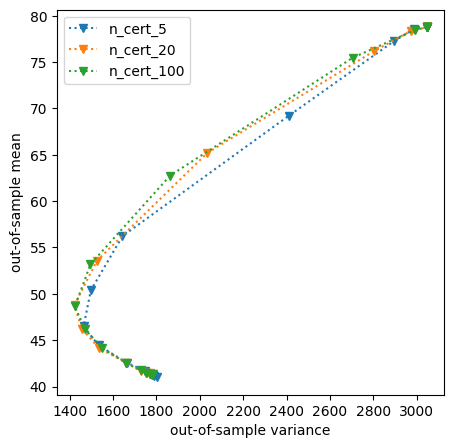

In [22]:
fig, axis = plt.subplots(nrows=1, ncols=1, sharex=False, sharey=False, figsize=(5,5))
for ncert in n_cert_values:
   dfn = df.xs(ncert, level='ncert')
   var = dfn["var_cost"]["mean"] + dfn["mean_cost"]["var"]
   axis.plot(var, dfn["mean_cost"]["mean"], marker="v", linestyle="dotted", label=f"n_cert_{ncert}")
axis.legend()
axis.set_xlabel("out-of-sample variance")
axis.set_ylabel("out-of-sample mean")

plt.show()

Tolerance level

In [11]:
def calculate_opt_tol(num_observations, kernel_bound, concentration_param, delta, inf_mmd):
    N = num_observations
    M = kernel_bound
    a = concentration_param 
    first_term = np.sqrt(M/N) 
    second_term = np.sqrt((2*M*(N-1)+ a*(a+1))/((a+N)*(a+N+1)))
    third_term = np.sqrt((M*a*(a+1))/((a+N)*(a+N+1)))
    fourth_term = np.sqrt(2*N*M*np.log(1/delta))/(a+N)
    return 2*(first_term+second_term+third_term+fourth_term) + inf_mmd

In [21]:
print(calculate_opt_tol(20,1,0,0.2,0))

1.851154811890592
